# RoboVision — Drawing Primitives & Text Placement
Tests all drawing functions on blank canvases and on a real photo.

**Shift+Enter** to run each cell.

In [1]:
import pathlib

# Recreate both __init__.py files as truly empty
p1 = pathlib.Path(r"D:\data ssd\machine vision\machine vision project\milestone 1\robovision\robovision\__init__.py")
p2 = pathlib.Path(r"D:\data ssd\machine vision\machine vision project\milestone 1\robovision\robovision\utils\__init__.py")

p1.write_text("")
p2.write_text("")

print("Done — both __init__.py recreated cleanly")
print("p1 size:", p1.stat().st_size, "bytes  (should be 0)")
print("p2 size:", p2.stat().st_size, "bytes  (should be 0)")

Done — both __init__.py recreated cleanly
p1 size: 0 bytes  (should be 0)
p2 size: 0 bytes  (should be 0)


In [2]:
import sys
PROJECT_ROOT = r"D:\data ssd\machine vision\machine vision project\milestone 1\robovision"
for k in list(sys.modules):
    if 'robovision' in k: del sys.modules[k]
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 130

from robovision.io.image_io           import read_image
from robovision.transforms.resize      import resize
from robovision.utils.drawing_primitives import (
    draw_point, draw_line, draw_line_aa,
    draw_rectangle, draw_polygon, draw_ellipse
)
from robovision.utils.text_placement   import draw_text, get_text_size

def blank(h=300, w=400, rgb=True, val=0.08):
    """Create a near-black canvas for drawing."""
    if rgb:
        return np.full((h, w, 3), val, dtype=np.float32)
    return np.full((h, w), val, dtype=np.float32)

def show(canvas, title=''):
    plt.figure(figsize=(7, 5))
    if canvas.ndim == 2:
        plt.imshow(np.clip(canvas, 0, 1), cmap='gray', vmin=0, vmax=1)
    else:
        plt.imshow(np.clip(canvas, 0, 1))
    plt.title(title, fontsize=11); plt.axis('off'); plt.tight_layout(); plt.show()

print('imports OK')

imports OK


In [3]:
IMG_PATH = r"D:\data ssd\machine vision\happy cesar.png"
photo = read_image(IMG_PATH)[:,:,:3]
photo = resize(photo, (300, 400), 'bilinear').copy()
print(f'Photo: {photo.shape}  dtype: {photo.dtype}')

Photo: (300, 400, 3)  dtype: float32


---
## draw_point — single pixel and filled circle

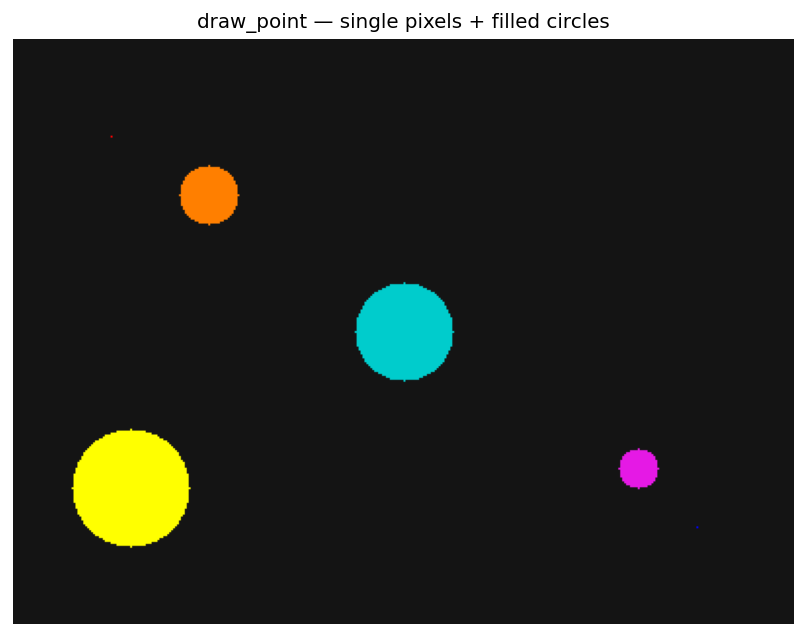

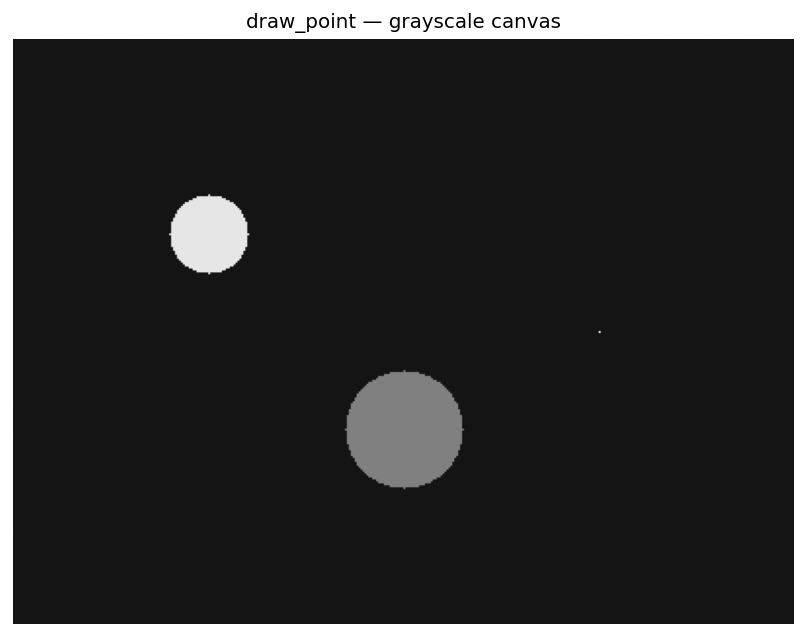

draw_point ✓


In [4]:
c = blank()

# Single pixels
for x, y, col in [(50,50,(1,0,0)), (200,150,(0,1,0)), (350,250,(0,0,1))]:
    draw_point(c, x, y, col, radius=0)

# Filled circles — various sizes
for x, y, r, col in [
    (100, 80,  15, (1.0, 0.5, 0.0)),
    (200, 150, 25, (0.0, 0.8, 0.8)),
    (320, 220, 10, (0.9, 0.1, 0.9)),
    (60,  230, 30, (1.0, 1.0, 0.0)),
]:
    draw_point(c, x, y, col, radius=r)

show(c, 'draw_point — single pixels + filled circles')

# Grayscale
g = blank(rgb=False)
draw_point(g, 100, 100, 0.9, radius=20)
draw_point(g, 200, 200, 0.5, radius=30)
draw_point(g, 300, 150, 1.0, radius=0)
show(g, 'draw_point — grayscale canvas')

# Assertions
t = blank()
draw_point(t, 50, 50, (1,0,0), radius=5)
assert t[50, 50, 0] == 1.0          # centre is red
assert t[50, 56, 0] == 0.08         # outside radius is background
print('draw_point ✓')

---
## draw_line — Bresenham + thickness

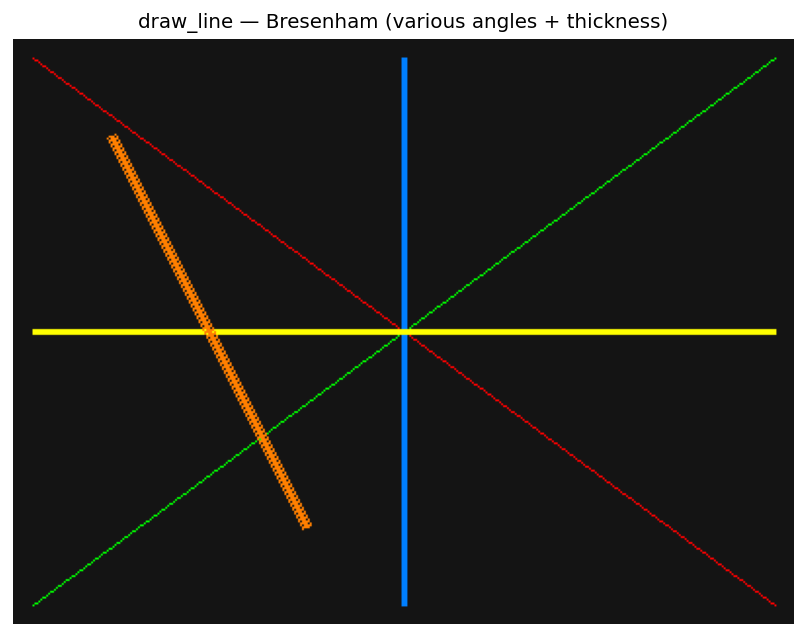

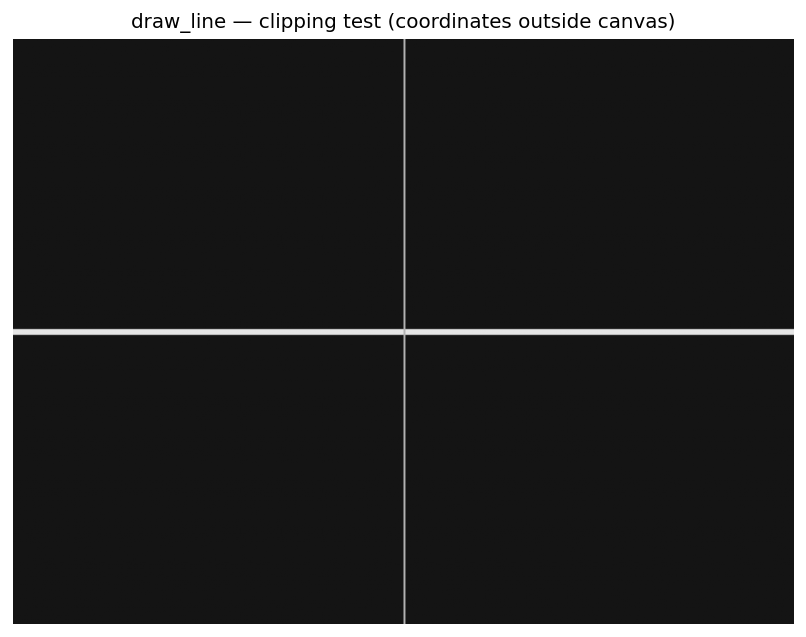

draw_line ✓


In [5]:
c = blank()

# Various angles
draw_line(c,  10,  10, 390, 290, (1, 0, 0),         thickness=1)  # diagonal
draw_line(c,  10, 290, 390,  10, (0, 1, 0),         thickness=1)  # other diagonal
draw_line(c, 200,  10, 200, 290, (0, 0.5, 1),       thickness=3)  # vertical thick
draw_line(c,  10, 150, 390, 150, (1, 1, 0),         thickness=2)  # horizontal
draw_line(c,  50,  50, 150, 250, (1, 0.5, 0),       thickness=5)  # thick

show(c, 'draw_line — Bresenham (various angles + thickness)')

# Grayscale + clipping test (start outside canvas)
g = blank(rgb=False)
draw_line(g, -50, 150, 450, 150, 0.9, thickness=2)   # extends beyond both edges
draw_line(g, 200, -50, 200, 350, 0.7, thickness=1)   # extends beyond top/bottom
show(g, 'draw_line — clipping test (coordinates outside canvas)')

t = blank(h=100, w=100)
draw_line(t, 0, 0, 99, 99, (1,1,1), thickness=1)
assert t[0, 0, 0] == 1.0 and t[99, 99, 0] == 1.0
print('draw_line ✓')

---
## draw_line_aa — Wu anti-aliased line

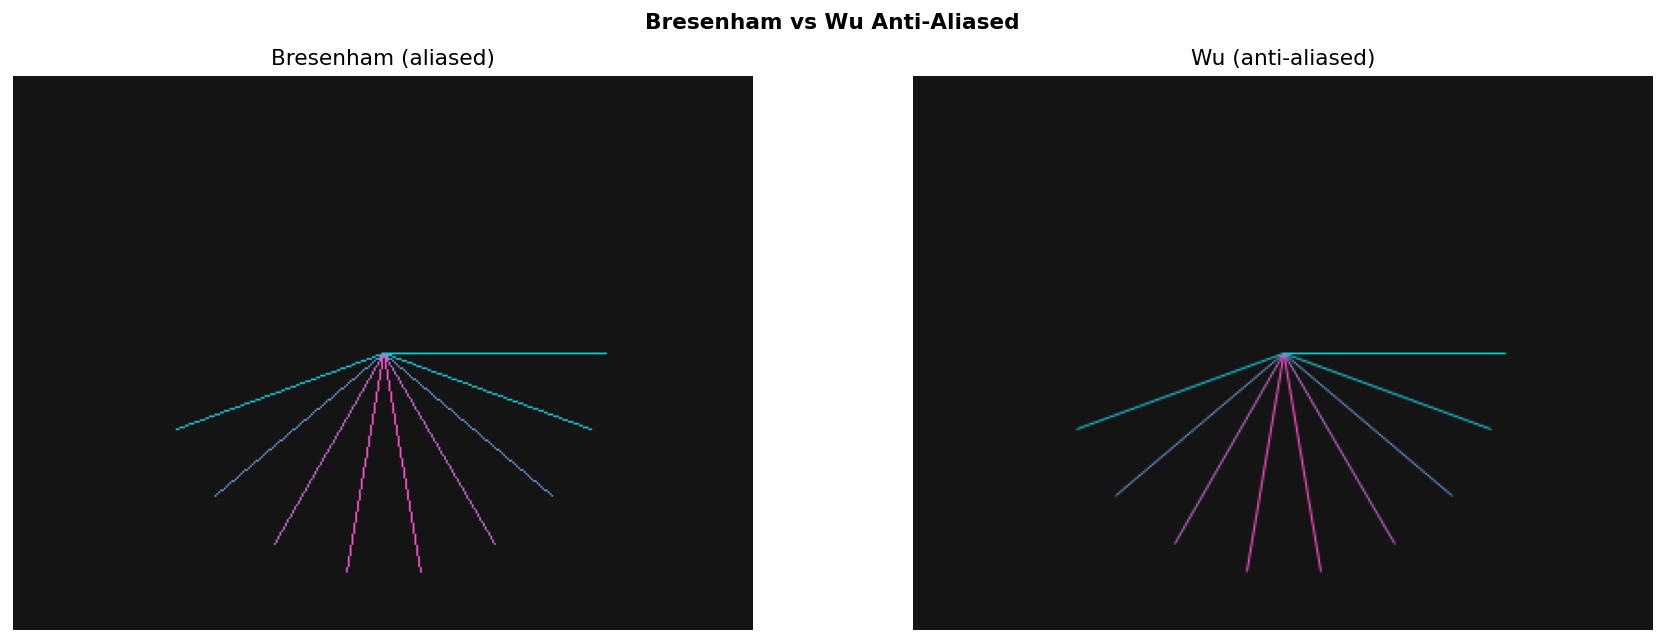

draw_line_aa ✓


In [6]:
c_aliased = blank()
c_aa      = blank()

# Same line drawn both ways — zoom in to see the difference
for angle_deg in range(0, 180, 20):
    import math
    rad = math.radians(angle_deg)
    cx, cy = 200, 150
    dx, dy = int(120 * math.cos(rad)), int(120 * math.sin(rad))
    col = (math.sin(rad)**2, math.cos(rad)**2*0.5+0.3, 0.8)
    draw_line(   c_aliased, cx, cy, cx+dx, cy+dy, col, thickness=1)
    draw_line_aa(c_aa,      cx, cy, cx+dx, cy+dy, col, thickness=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bresenham vs Wu Anti-Aliased', fontsize=12, fontweight='bold')
axes[0].imshow(np.clip(c_aliased, 0, 1)); axes[0].set_title('Bresenham (aliased)'); axes[0].axis('off')
axes[1].imshow(np.clip(c_aa,      0, 1)); axes[1].set_title('Wu (anti-aliased)');   axes[1].axis('off')
plt.tight_layout(); plt.show()

print('draw_line_aa ✓')

---
## draw_rectangle — filled + outline

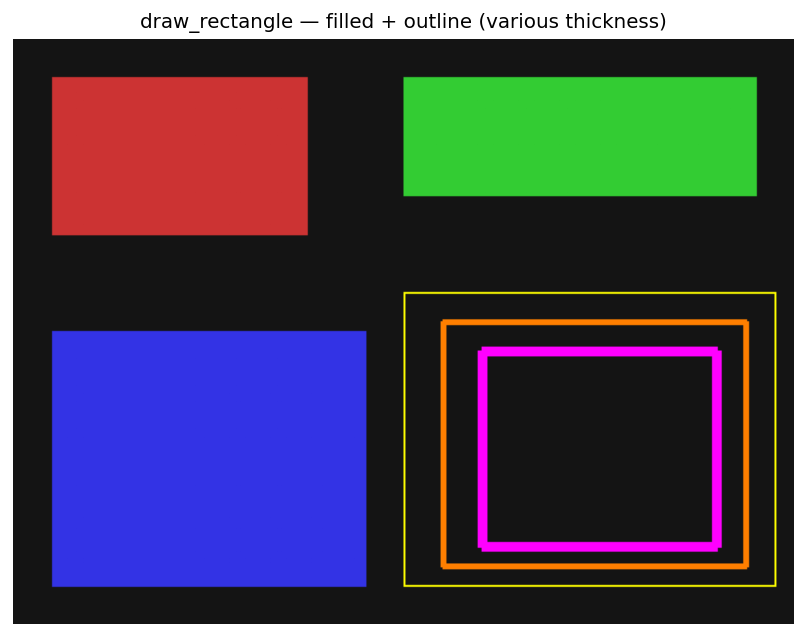

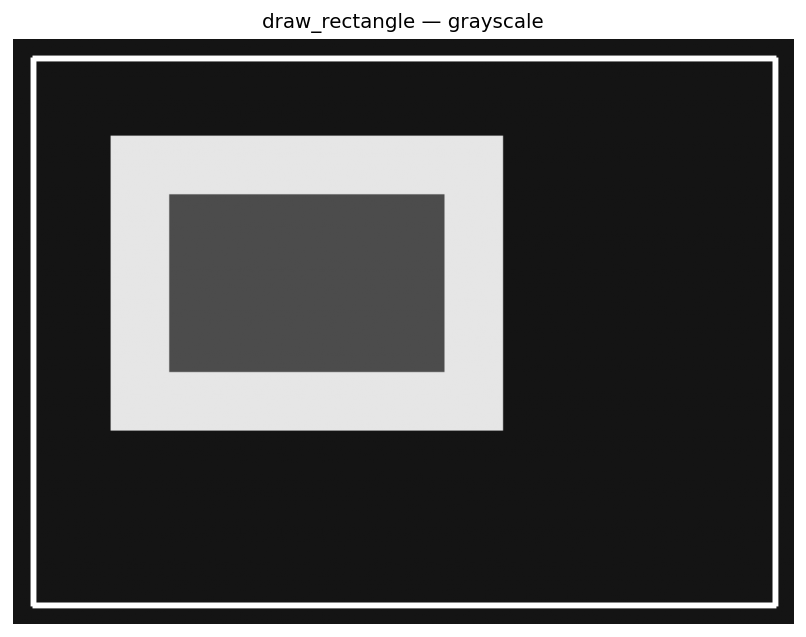

draw_rectangle ✓


In [7]:
c = blank()

# Filled rectangles
draw_rectangle(c,  20,  20, 150, 100, (0.8, 0.2, 0.2), filled=True)
draw_rectangle(c, 200,  20, 380,  80, (0.2, 0.8, 0.2), filled=True)
draw_rectangle(c,  20, 150, 180, 280, (0.2, 0.2, 0.9), filled=True)

# Outline rectangles — various thickness
draw_rectangle(c, 200, 130, 390, 280, (1.0, 1.0, 0.0), filled=False, thickness=1)
draw_rectangle(c, 220, 145, 375, 270, (1.0, 0.5, 0.0), filled=False, thickness=3)
draw_rectangle(c, 240, 160, 360, 260, (1.0, 0.0, 1.0), filled=False, thickness=5)

show(c, 'draw_rectangle — filled + outline (various thickness)')

# Grayscale
g = blank(rgb=False)
draw_rectangle(g, 50, 50, 250, 200, 0.9, filled=True)
draw_rectangle(g, 80, 80, 220, 170, 0.3, filled=True)
draw_rectangle(g, 10, 10, 390, 290, 1.0, filled=False, thickness=3)
show(g, 'draw_rectangle — grayscale')

t = blank(h=100, w=100)
draw_rectangle(t, 10, 10, 50, 50, (1,0,0), filled=True)
assert t[30, 30, 0] == 1.0    # inside filled region
assert t[5,  30, 0] == 0.08   # outside
print('draw_rectangle ✓')

---
## draw_polygon — outline + filled

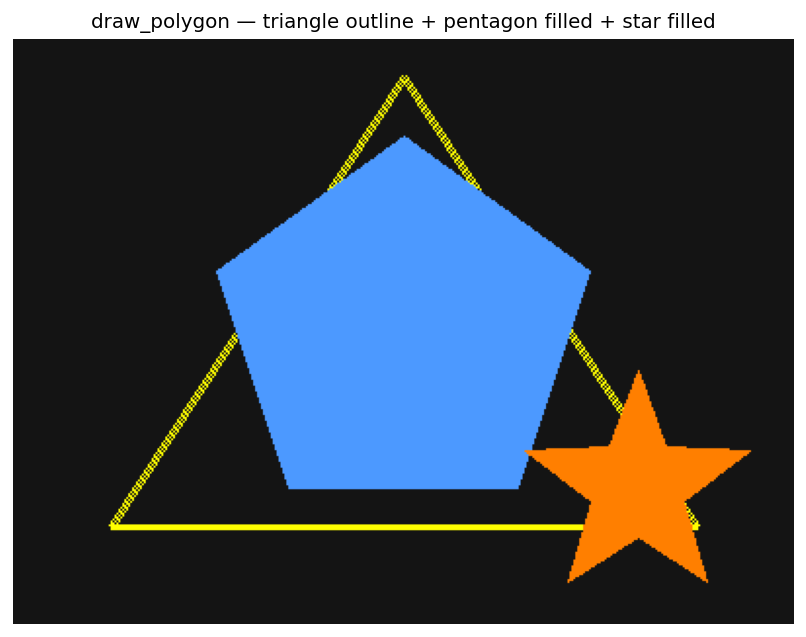

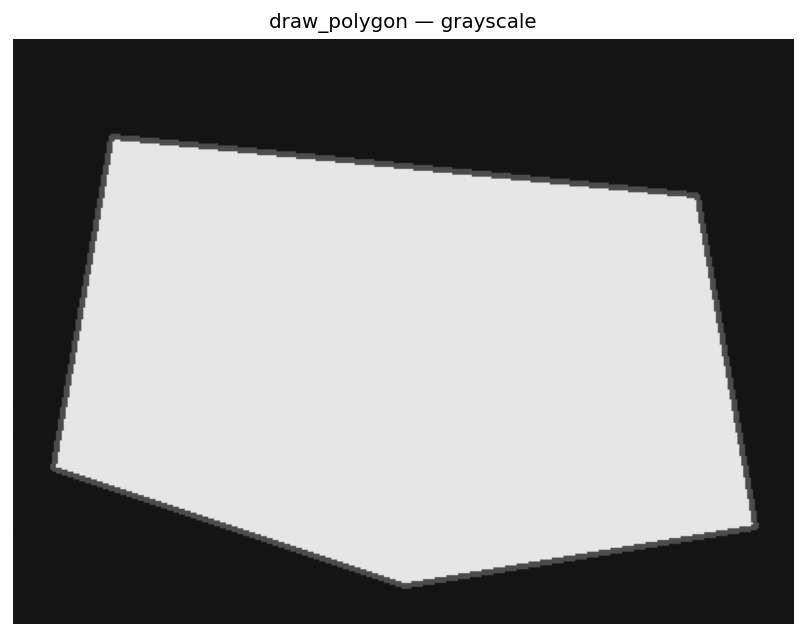

draw_polygon ✓


In [8]:
c = blank()

# Triangle — outline
draw_polygon(c, [(200,20),(50,250),(350,250)],  color=(1,1,0),   filled=False, thickness=2)
# Pentagon — filled
import math
cx, cy, r = 200, 150, 100
penta = [(int(cx + r*math.cos(math.radians(90+72*i))),
           int(cy - r*math.sin(math.radians(90+72*i)))) for i in range(5)]
draw_polygon(c, penta, color=(0.3,0.6,1.0), filled=True)
# Star — outline only
star = []
for i in range(10):
    rad_r = 60 if i%2==0 else 25
    a = math.radians(-90 + 36*i)
    star.append((int(320 + rad_r*math.cos(a)), int(230 + rad_r*math.sin(a))))
draw_polygon(c, star, color=(1,0.5,0), filled=True)

show(c, 'draw_polygon — triangle outline + pentagon filled + star filled')

# Grayscale polygon
g = blank(rgb=False)
draw_polygon(g, [(50,50),(350,80),(380,250),(200,280),(20,220)], 0.9, filled=True)
draw_polygon(g, [(50,50),(350,80),(380,250),(200,280),(20,220)], 0.3, filled=False, thickness=2)
show(g, 'draw_polygon — grayscale')

print('draw_polygon ✓')

---
## draw_ellipse — filled + outline

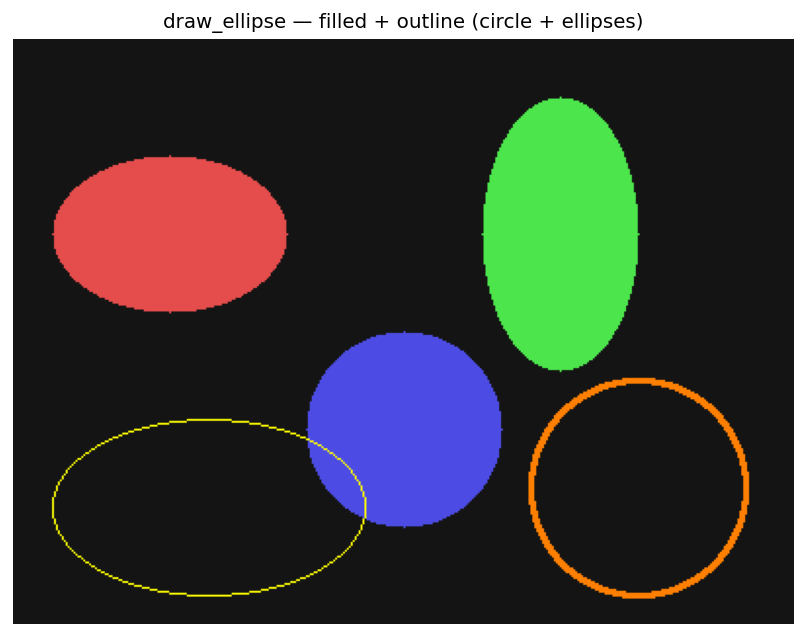

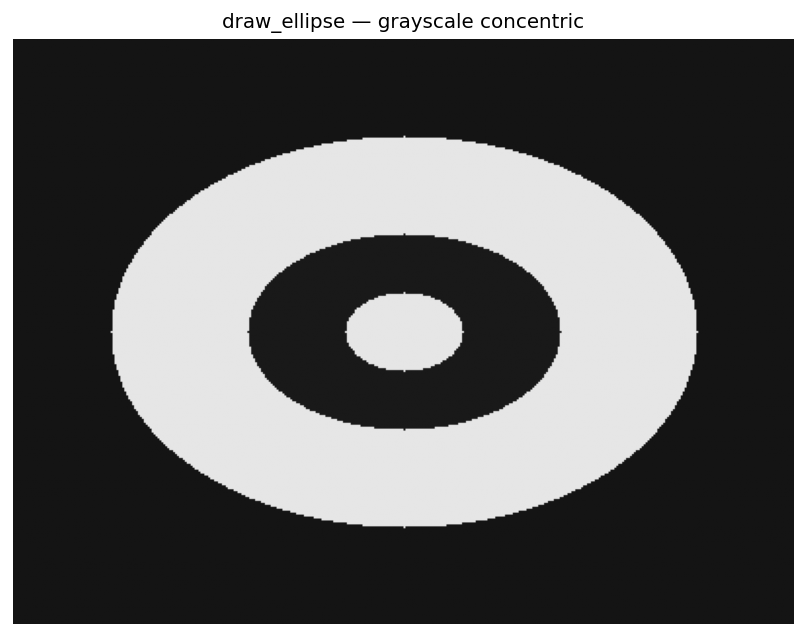

draw_ellipse ✓


In [9]:
c = blank()

# Filled ellipses
draw_ellipse(c,  80, 100, 60, 40, (0.9, 0.3, 0.3), filled=True)
draw_ellipse(c, 280, 100, 40, 70, (0.3, 0.9, 0.3), filled=True)
# Circles (rx == ry)
draw_ellipse(c, 200, 200, 50, 50, (0.3, 0.3, 0.9), filled=True)
# Outline ellipses — various thickness
draw_ellipse(c, 100, 240, 80, 45, (1.0, 1.0, 0.0), filled=False, thickness=1)
draw_ellipse(c, 320, 230, 55, 55, (1.0, 0.5, 0.0), filled=False, thickness=3)

show(c, 'draw_ellipse — filled + outline (circle + ellipses)')

# Grayscale
g = blank(rgb=False)
draw_ellipse(g, 200, 150, 150, 100, 0.9, filled=True)
draw_ellipse(g, 200, 150,  80,  50, 0.1, filled=True)
draw_ellipse(g, 200, 150,  30,  20, 0.9, filled=True)
show(g, 'draw_ellipse — grayscale concentric')

t = blank(h=100, w=100)
draw_ellipse(t, 50, 50, 30, 20, (1,0,0), filled=True)
assert t[50, 50, 0] == 1.0     # centre
assert t[50, 90, 0] == 0.08   # outside
print('draw_ellipse ✓')

---
## draw_text — position, scale, color

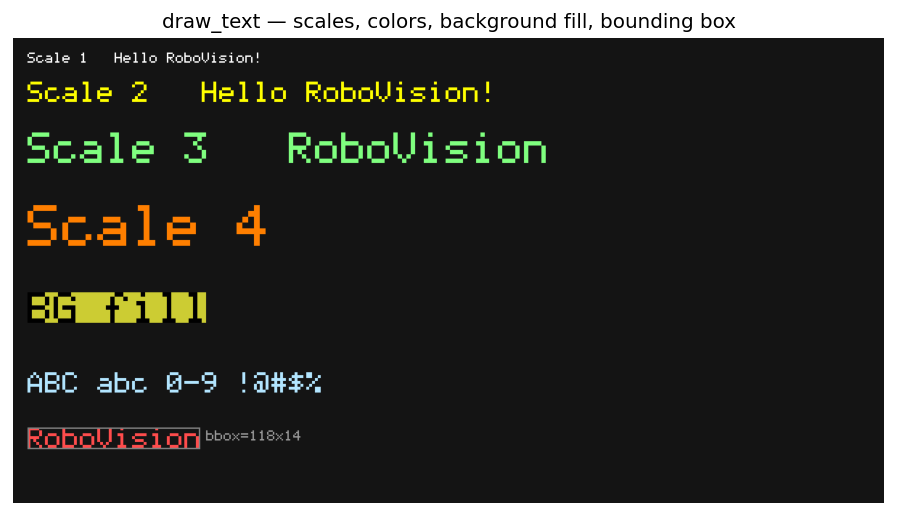

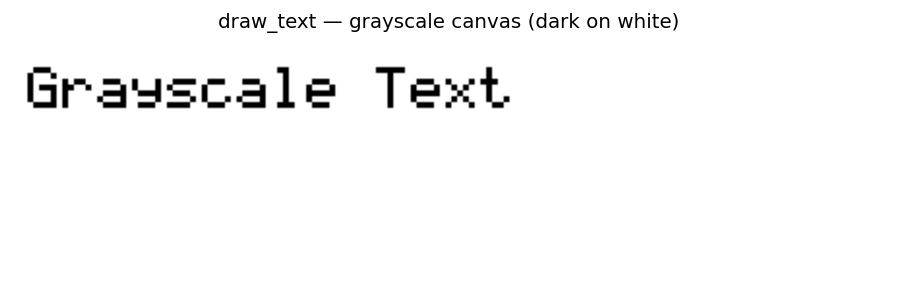

draw_text ✓


In [10]:
c = blank(h=320, w=600)

# Different scales
draw_text(c, 'Scale 1 — Hello RoboVision!', x=10, y=10,  color=(1,1,1),       scale=1)
draw_text(c, 'Scale 2 — Hello RoboVision!', x=10, y=30,  color=(1,1,0),       scale=2)
draw_text(c, 'Scale 3 — RoboVision',        x=10, y=65,  color=(0.5,1,0.5),   scale=3)
draw_text(c, 'Scale 4',                     x=10, y=115, color=(1,0.5,0),     scale=4)

# Background fill
draw_text(c, 'BG fill', x=10, y=175, color=(0,0,0), scale=3,
          background_color=(0.8, 0.8, 0.2))

# All printable ASCII
draw_text(c, 'ABC abc 0-9 !@#$%', x=10, y=230, color=(0.7,0.9,1), scale=2)

# get_text_size
w2, h2 = get_text_size('RoboVision', scale=2)
draw_text(c, 'RoboVision', x=10, y=268, color=(1,0.3,0.3), scale=2)
draw_rectangle(c, 10, 268, 10+w2, 268+h2, (0.5,0.5,0.5), filled=False, thickness=1)
draw_text(c, f'bbox={w2}x{h2}', x=10+w2+5, y=270, color=(0.6,0.6,0.6), scale=1)

show(c, 'draw_text — scales, colors, background fill, bounding box')

# Grayscale
g = blank(h=80, w=300, rgb=False, val=1.0)
draw_text(g, 'Grayscale Text', x=5, y=10, color=0.0, scale=2)
show(g, 'draw_text — grayscale canvas (dark on white)')

# Assertions
w, h = get_text_size('A', scale=1)
assert w == 5 and h == 7
w, h = get_text_size('AB', scale=2)
assert h == 14
print('draw_text ✓')

---
## Combined — all primitives + text on photo

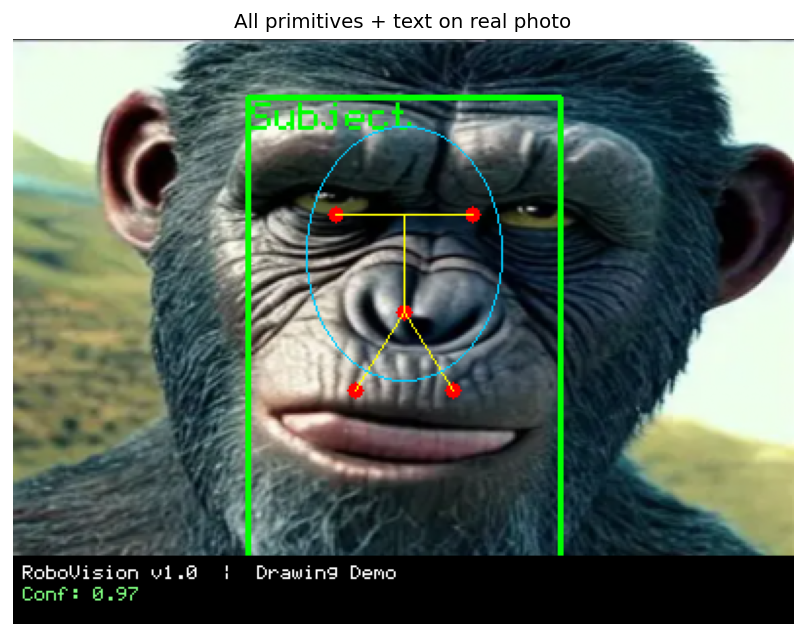

Combined drawing demo ✓


In [11]:
canvas = photo.copy()

# Detection box
draw_rectangle(canvas, 120, 30, 280, 270, (0,1,0), filled=False, thickness=2)
draw_text(canvas, 'Subject', x=122, y=33, color=(0,1,0), scale=2)

# Keypoints
for x, y in [(165,90),(235,90),(200,140),(175,180),(225,180)]:
    draw_point(canvas, x, y, (1,0,0), radius=4)

# Skeleton lines
draw_line(canvas, 165,90, 235,90,  (1,1,0), thickness=1)
draw_line(canvas, 200,90, 200,140, (1,1,0), thickness=1)
draw_line(canvas, 200,140,175,180, (1,1,0), thickness=1)
draw_line(canvas, 200,140,225,180, (1,1,0), thickness=1)

# Ellipse around head
draw_ellipse(canvas, 200, 110, 50, 65, (0,0.8,1), filled=False, thickness=1)

# Info panel
draw_rectangle(canvas, 0, 265, 400, 300, (0,0,0), filled=True)
draw_text(canvas, 'RoboVision v1.0  |  Drawing Demo', x=5, y=270, color=(1,1,1), scale=1)
draw_text(canvas, 'Conf: 0.97', x=5, y=281, color=(0.5,1,0.5), scale=1)

show(canvas, 'All primitives + text on real photo')
print('Combined drawing demo ✓')

---
## Error Handling

In [12]:
c = blank()
tests = [
    # draw_point
    (lambda: draw_point('x', 10, 10, 0.5),           TypeError,  'point bad canvas'),
    (lambda: draw_point(c,   10, 10, (1,0)),          ValueError, 'point bad color'),
    # draw_line
    (lambda: draw_line(c,0,0,10,10,(1,0,0), thickness=0), ValueError, 'line thickness=0'),
    (lambda: draw_line(c,0,0,10,10,(1,0,0), thickness=1.5), TypeError, 'line float thick'),
    # draw_rectangle
    (lambda: draw_rectangle('x',0,0,10,10,0.5),      TypeError,  'rect bad canvas'),
    # draw_polygon
    (lambda: draw_polygon(c, [(10,10)], (1,0,0)),     ValueError, 'polygon < 2 pts'),
    (lambda: draw_polygon(c, 'pts', (1,0,0)),         TypeError,  'polygon bad pts type'),
    # draw_ellipse
    (lambda: draw_ellipse(c,100,100,0,20,(1,0,0)),    ValueError, 'ellipse rx=0'),
    (lambda: draw_ellipse(c,100,100,20,-1,(1,0,0)),   ValueError, 'ellipse ry<1'),
    # draw_text
    (lambda: draw_text(c, 123, 10, 10, (1,1,1)),      TypeError,  'text not str'),
    (lambda: draw_text(c, 'hi',10,10,(1,1,1),scale=0),ValueError, 'text scale=0'),
    (lambda: draw_text(c, 'hi',10,10,(1,1,1),scale=1.5),ValueError,'text float scale'),
    # get_text_size
    (lambda: get_text_size(123),                      TypeError,  'text_size bad type'),
    (lambda: get_text_size('hi', scale=-1),           ValueError, 'text_size neg scale'),
    # grayscale color mismatch
    (lambda: draw_point(blank(rgb=False),10,10,(1,0,0)),TypeError,'gray canvas rgb color'),
]

all_ok = True
for fn, exc, label in tests:
    try:
        fn(); print(f'  FAIL  {label}'); all_ok = False
    except exc:
        print(f'  OK    {label}')
    except Exception as e:
        print(f'  WRONG {label} → {type(e).__name__}: {e}'); all_ok = False

print('\nAll error tests passed ✓' if all_ok else '\nSome FAILED ❌')

  OK    point bad canvas
  OK    point bad color
  OK    line thickness=0
  OK    line float thick
  OK    rect bad canvas
  OK    polygon < 2 pts
  OK    polygon bad pts type
  OK    ellipse rx=0
  OK    ellipse ry<1
  OK    text not str
  OK    text scale=0
  OK    text float scale
  OK    text_size bad type
  OK    text_size neg scale
  OK    gray canvas rgb color

All error tests passed ✓
